<a href="https://colab.research.google.com/github/Uchihatt/My-Projects/blob/main/Diabetes_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================
# 0) SETUP (Colab-friendly)
# ============================================
# If you're on Google Colab, run installs once:
!pip -q install optuna shap xgboost imbalanced-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
import optuna
import shap

RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 120

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.4 MB/s eta 0:00:00


In [3]:
# ============================================
# 1) LOAD DATA (Colab upload)
# ============================================
from google.colab import files
uploaded = files.upload()  # choose diabetes.csv
path = list(uploaded.keys())[0]

df = pd.read_csv(path)
df.head()


Saving diabetes.csv to diabetes (1).csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# ============================================
# 2) QUICK AUDIT
# ============================================
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nOutcome distribution:\n", df["Outcome"].value_counts())
print("\nOutcome rate (positive %):", round(df["Outcome"].mean()*100, 2))

df.describe().T


Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Outcome distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64

Outcome rate (positive %): 34.9


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [5]:
# ============================================
# 3) IMPORTANT: Treat 0s as "missing" for medical fields (Pima-style)
# In this dataset, 0 usually means missing for:
# Glucose, BloodPressure, SkinThickness, Insulin, BMI
# ============================================
zero_as_missing = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

df_clean = df.copy()
for c in zero_as_missing:
    df_clean.loc[df_clean[c] == 0, c] = np.nan

# Check missingness after conversion
missing_pct = df_clean.isna().mean().sort_values(ascending=False) * 100
missing_pct


,0
Insulin,48.697917
SkinThickness,29.557292
BloodPressure,4.557292
BMI,1.432292
Glucose,0.651042
Pregnancies,0.000000
DiabetesPedigreeFunction,0.000000
Age,0.000000
Outcome,0.000000


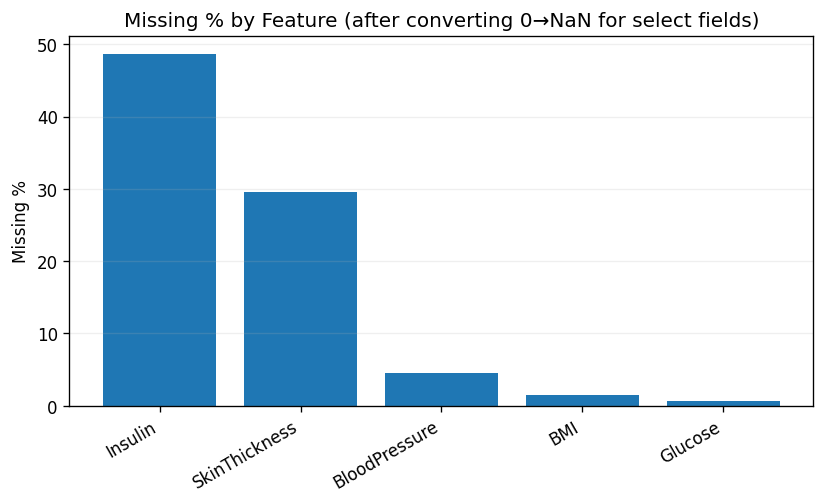

In [6]:
# ============================================
# 4) VISUAL 1: Missingness / zero-as-missing bar chart
# ============================================
vals = missing_pct[missing_pct > 0]

plt.figure(figsize=(8,4))
plt.bar(vals.index, vals.values)
plt.title("Missing % by Feature (after converting 0→NaN for select fields)")
plt.ylabel("Missing %")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.show()


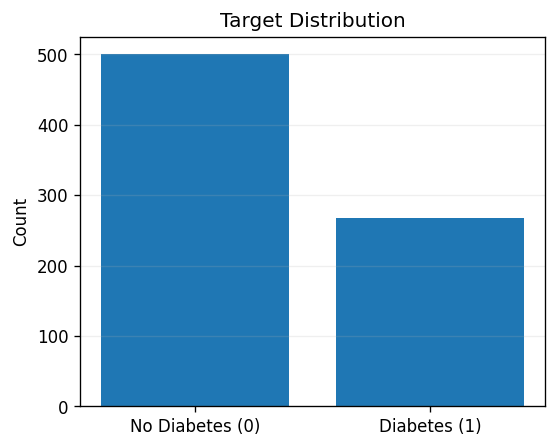

In [7]:
# ============================================
# 5) VISUAL 2: Outcome distribution
# ============================================
counts = df_clean["Outcome"].value_counts().sort_index()
labels = ["No Diabetes (0)", "Diabetes (1)"]

plt.figure(figsize=(5,4))
plt.bar(labels, counts.values)
plt.title("Target Distribution")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.2)
plt.show()


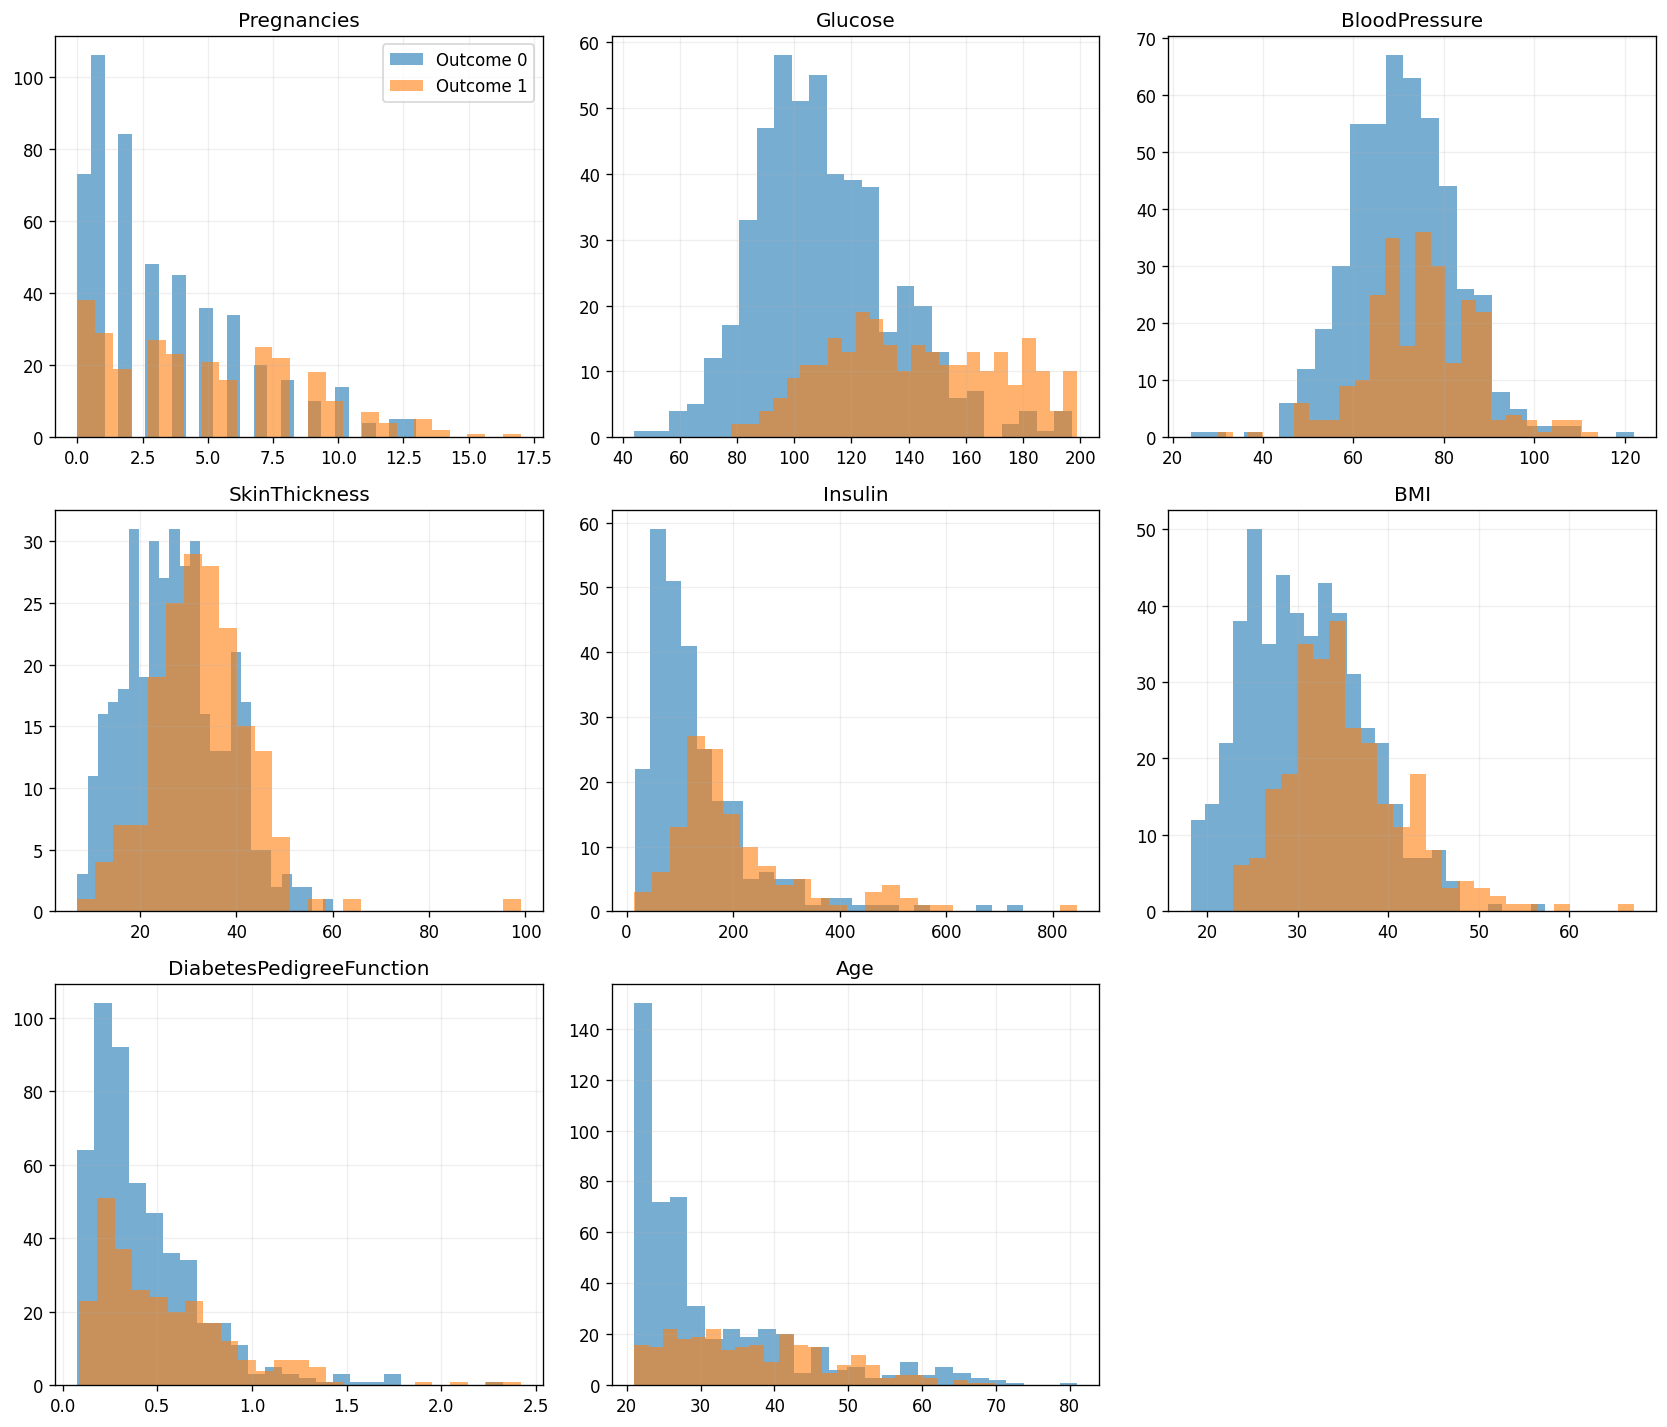

In [8]:
# ============================================
# 6) VISUAL 3: Feature histograms by Outcome (clean + readable)
# (Matplotlib only; no seaborn)
# ============================================
features = [c for c in df_clean.columns if c != "Outcome"]

ncols = 3
nrows = int(np.ceil(len(features)/ncols))
plt.figure(figsize=(14, 4*nrows))

for i, col in enumerate(features, 1):
    ax = plt.subplot(nrows, ncols, i)
    x0 = df_clean.loc[df_clean["Outcome"]==0, col].dropna()
    x1 = df_clean.loc[df_clean["Outcome"]==1, col].dropna()
    ax.hist(x0, bins=25, alpha=0.6, label="Outcome 0")
    ax.hist(x1, bins=25, alpha=0.6, label="Outcome 1")
    ax.set_title(col)
    ax.grid(alpha=0.2)
    if i == 1:
        ax.legend()

plt.tight_layout()
plt.show()


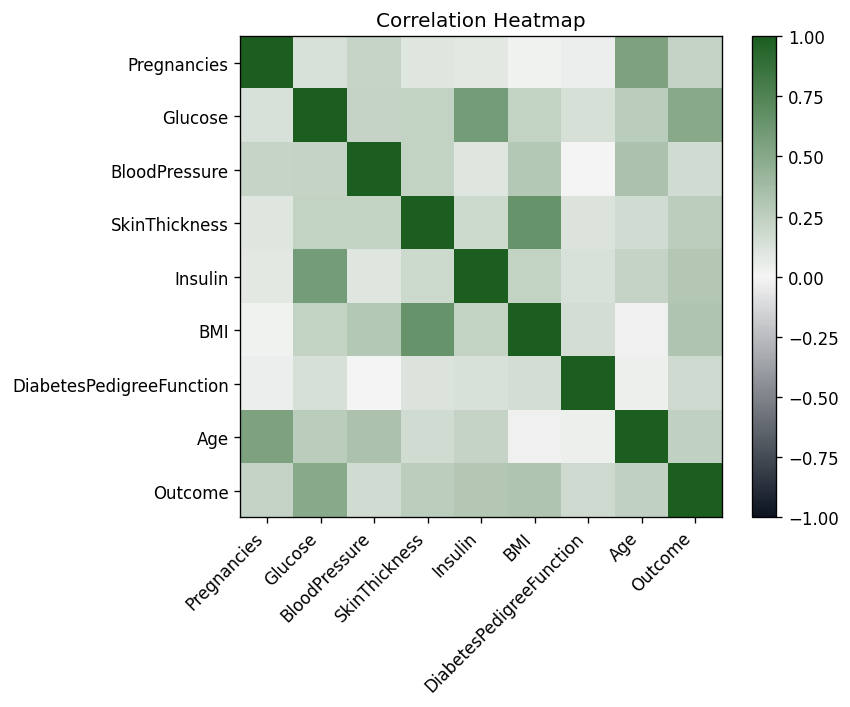

In [9]:
# ============================================
# 7) VISUAL 4: Correlation heatmap (matplotlib)
# ============================================
corr = df_clean.corr(numeric_only=True)

# Nice-looking (but still matplotlib) colormap:
cmap = LinearSegmentedColormap.from_list("soft", ["#0B1320", "#F5F5F5", "#1B5E20"])

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
plt.colorbar(fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [10]:
# ============================================
# 8) TRAIN/TEST SPLIT
# ============================================
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape


((614, 8), (154, 8))

In [11]:
# ============================================
# 9) PREPROCESSING PIPELINE (impute + scale)
# ============================================
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [13]:
# ============================================
# 10) MODEL 1: Strong baseline (Logistic Regression) + SMOTE
# Why SMOTE? Helps if class imbalance exists.
# ============================================
log_reg = ImbPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)

proba_lr = log_reg.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

print("LogReg ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 4))
print("LogReg PR-AUC :", round(average_precision_score(y_test, proba_lr), 4))
print("\n", classification_report(y_test, pred_lr))

LogReg ROC-AUC: 0.8113
LogReg PR-AUC : 0.6758

               precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.57      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.68      0.69      0.69       154
weighted avg       0.72      0.71      0.71       154



<Figure size 720x600 with 0 Axes>

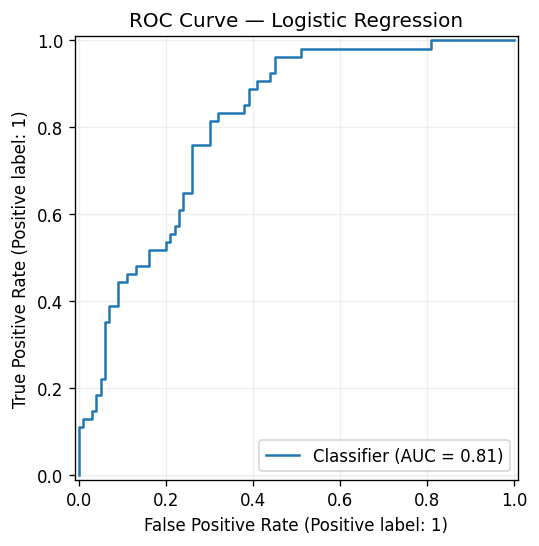

<Figure size 720x600 with 0 Axes>

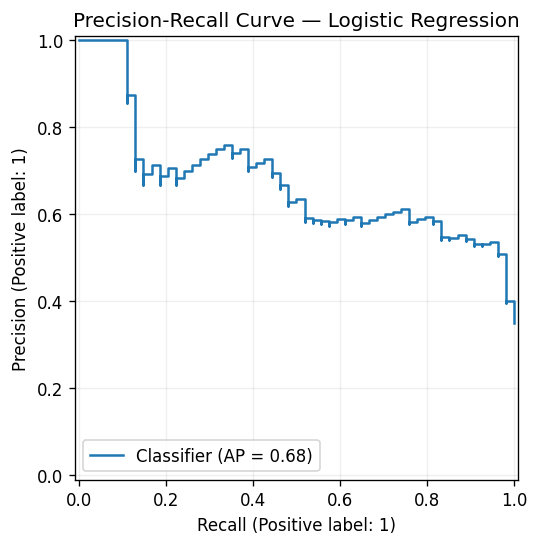

In [14]:
# ============================================
# 11) VISUAL: ROC + PR curves (LogReg)
# ============================================
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, proba_lr)
plt.title("ROC Curve — Logistic Regression")
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test, proba_lr)
plt.title("Precision-Recall Curve — Logistic Regression")
plt.grid(alpha=0.2)
plt.show()


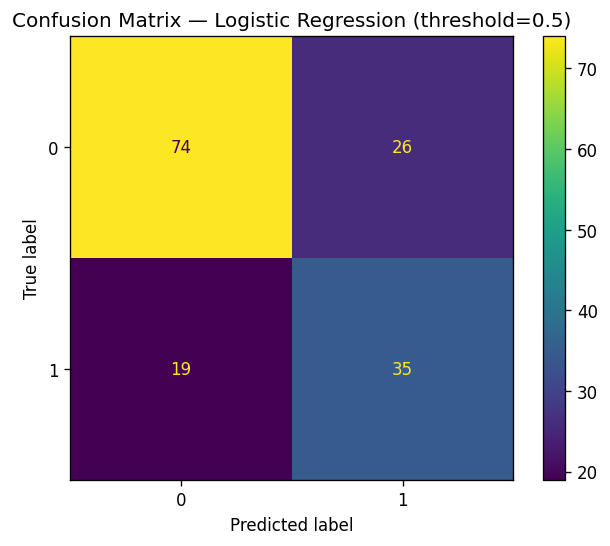

In [15]:
# ============================================
# 12) VISUAL: Confusion matrix (LogReg @ 0.5 threshold)
# ============================================
cm = confusion_matrix(y_test, pred_lr)
disp = ConfusionMatrixDisplay(cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (threshold=0.5)")
plt.show()


In [16]:
# ============================================
# 13) MODEL 2: Random Forest (robust + interpretable-ish)
# ============================================
rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.5).astype(int)

print("RF ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 4))
print("RF PR-AUC :", round(average_precision_score(y_test, proba_rf), 4))
print("\n", classification_report(y_test, pred_rf))


RF ROC-AUC: 0.8243
RF PR-AUC : 0.7082

               precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.65      0.66        54

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



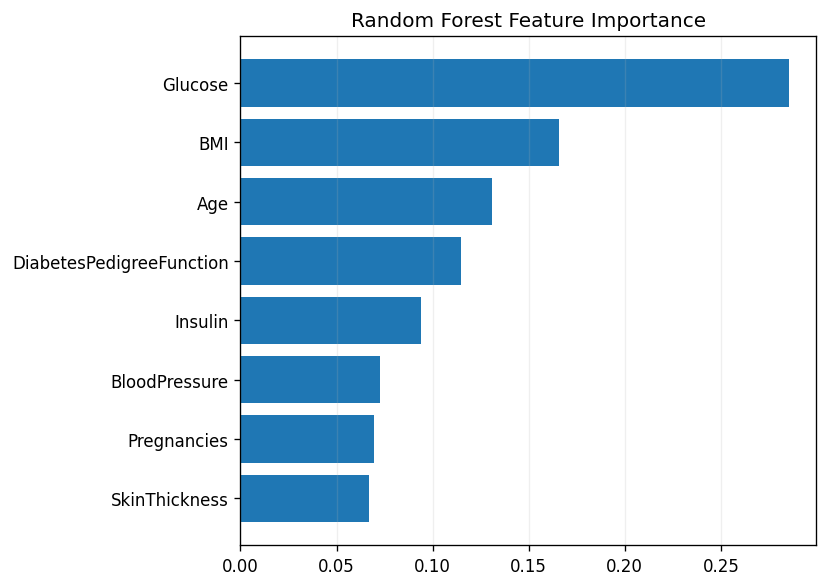

In [17]:
# ============================================
# 14) VISUAL: Random Forest feature importance (clean bar plot)
# ============================================
importances = rf.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values()

plt.figure(figsize=(7,5))
plt.barh(feat_imp.index, feat_imp.values)
plt.title("Random Forest Feature Importance")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


In [18]:
# ============================================
# 15) MODEL 3: XGBoost (usually top performer on this dataset)
# We'll tune with Optuna (professional-grade).
# ============================================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "random_state": RANDOM_STATE,
        "eval_metric": "logloss",
        "n_jobs": -1
    }

    model = XGBClassifier(**params)

    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),  # optional for trees but fine; keep consistent
        ("clf", model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X_train))

    for tr_idx, va_idx in cv.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        pipe.fit(X_tr, y_tr)
        oof[va_idx] = pipe.predict_proba(X_va)[:, 1]

    return roc_auc_score(y_train, oof)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

study.best_value, study.best_params


[I 2026-02-19 17:29:24,159] A new study created in memory with name: no-name-4978d3ca-8740-43c2-929c-c4c484de27fa


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-19 17:29:32,102] Trial 0 finished with value: 0.8282009345794392 and parameters: {'n_estimators': 1157, 'max_depth': 5, 'learning_rate': 0.01735591904356829, 'subsample': 0.7815991323445162, 'colsample_bytree': 0.9373215873916484, 'min_child_weight': 9, 'reg_lambda': 0.0019283890973987256, 'reg_alpha': 0.011342601411979418, 'gamma': 2.163228191962772}. Best is trial 0 with value: 0.8282009345794392.
[I 2026-02-19 17:29:34,416] Trial 1 finished with value: 0.8256191588785047 and parameters: {'n_estimators': 1113, 'max_depth': 4, 'learning_rate': 0.11183418098984212, 'subsample': 0.872672393199369, 'colsample_bytree': 0.6191934431479195, 'min_child_weight': 10, 'reg_lambda': 0.4084425516948134, 'reg_alpha': 0.4807803653778359, 'gamma': 1.3588019346962015}. Best is trial 0 with value: 0.8282009345794392.
[I 2026-02-19 17:29:36,884] Trial 2 finished with value: 0.8044976635514018 and parameters: {'n_estimators': 1187, 'max_depth': 2, 'learning_rate': 0.23247152770258392, 'subsam

(0.8396728971962617,
 {'n_estimators': 1000,
  'max_depth': 4,
  'learning_rate': 0.10454437607629169,
  'subsample': 0.9466381967408632,
  'colsample_bytree': 0.8495866457445158,
  'min_child_weight': 10,
  'reg_lambda': 0.052740997176062544,
  'reg_alpha': 0.30634148517644105,
  'gamma': 3.808327973626962})

In [19]:
# ============================================
# 16) Train best XGBoost on full training data
# ============================================
best_params = study.best_params
best_params.update({
    "random_state": RANDOM_STATE,
    "eval_metric": "logloss",
    "n_jobs": -1
})

xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(**best_params))
])

xgb.fit(X_train, y_train)

proba_xgb = xgb.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

print("XGB ROC-AUC:", round(roc_auc_score(y_test, proba_xgb), 4))
print("XGB PR-AUC :", round(average_precision_score(y_test, proba_xgb), 4))
print("\n", classification_report(y_test, pred_xgb))


XGB ROC-AUC: 0.8291
XGB PR-AUC : 0.7027

               precision    recall  f1-score   support

           0       0.80      0.86      0.83       100
           1       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



<Figure size 720x600 with 0 Axes>

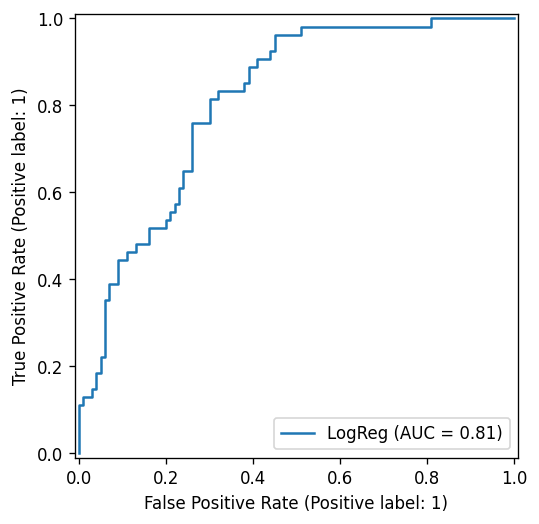

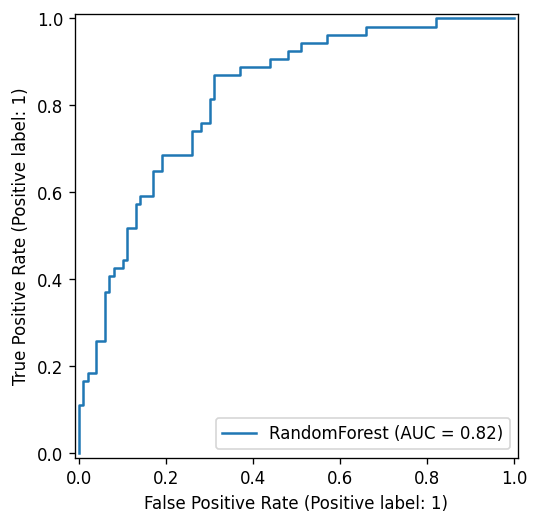

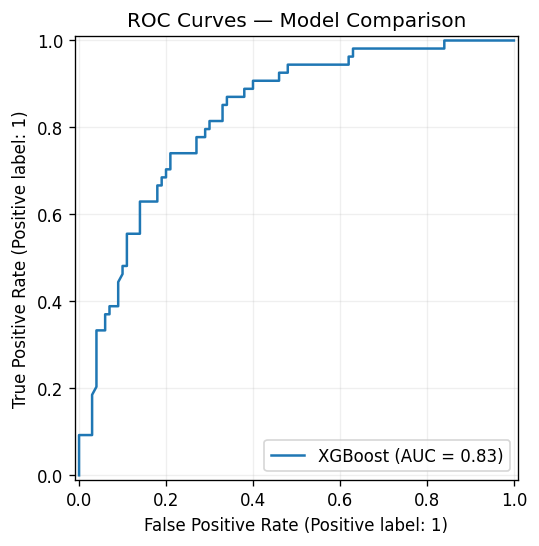

<Figure size 720x600 with 0 Axes>

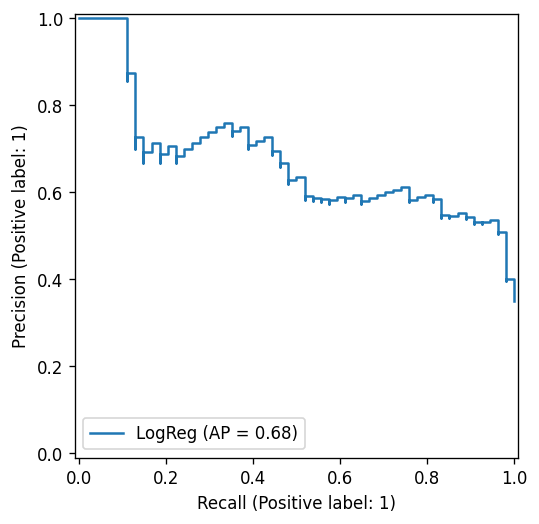

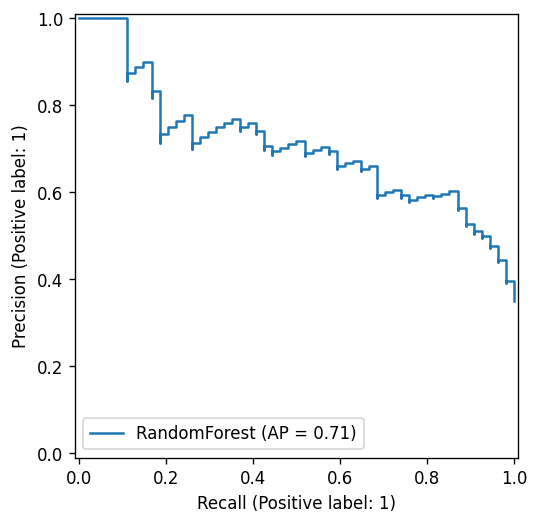

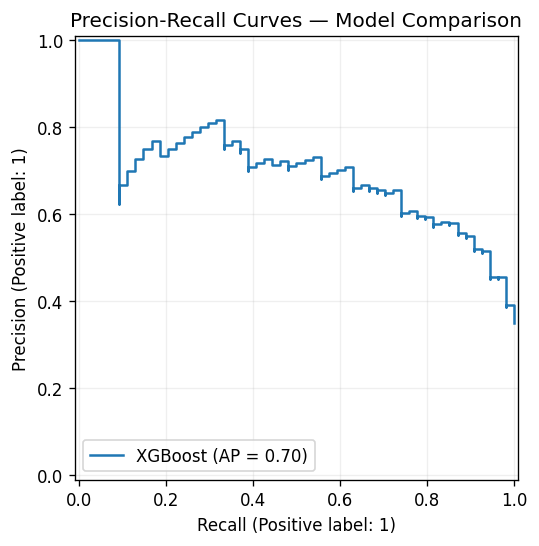

In [20]:
# ============================================
# 17) VISUAL: ROC + PR comparison (all models)
# ============================================
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, proba_lr, name="LogReg")
RocCurveDisplay.from_predictions(y_test, proba_rf, name="RandomForest")
RocCurveDisplay.from_predictions(y_test, proba_xgb, name="XGBoost")
plt.title("ROC Curves — Model Comparison")
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_test, proba_lr, name="LogReg")
PrecisionRecallDisplay.from_predictions(y_test, proba_rf, name="RandomForest")
PrecisionRecallDisplay.from_predictions(y_test, proba_xgb, name="XGBoost")
plt.title("Precision-Recall Curves — Model Comparison")
plt.grid(alpha=0.2)
plt.show()


Best threshold (by F1): 0.22  Best F1: 0.6963


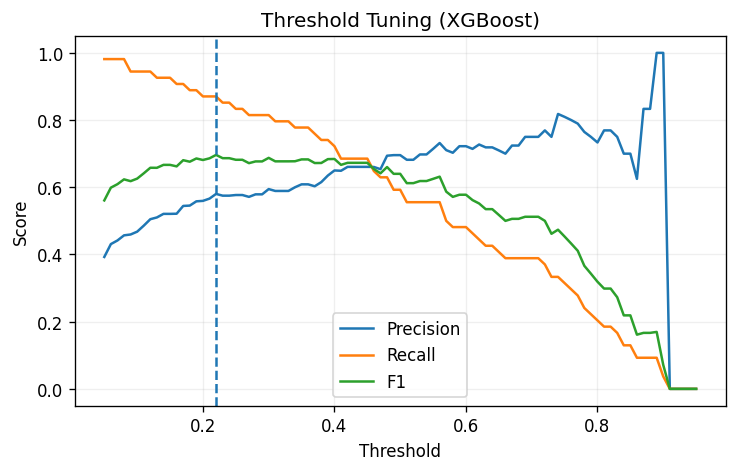

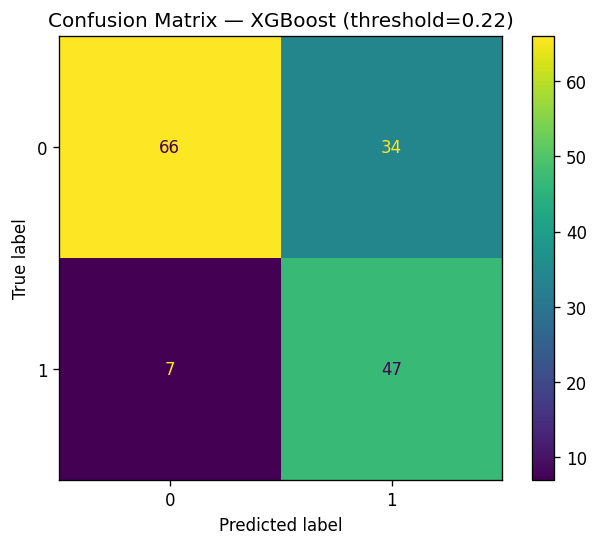

In [21]:
# ============================================
# 18) THRESHOLD TUNING (portfolio-level decision making)
# Example: choose threshold that maximizes F1 on the test set (demo)
# (In real life you do this on validation, not test.)
# ============================================
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(0.05, 0.95, 91)
f1s, ps, rs = [], [], []

for t in thresholds:
    pred = (proba_xgb >= t).astype(int)
    f1s.append(f1_score(y_test, pred))
    ps.append(precision_score(y_test, pred, zero_division=0))
    rs.append(recall_score(y_test, pred))

best_idx = int(np.argmax(f1s))
best_t = thresholds[best_idx]

print("Best threshold (by F1):", round(best_t, 3), " Best F1:", round(f1s[best_idx], 4))

plt.figure(figsize=(7,4))
plt.plot(thresholds, ps, label="Precision")
plt.plot(thresholds, rs, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.axvline(best_t, linestyle="--")
plt.title("Threshold Tuning (XGBoost)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

pred_xgb_best = (proba_xgb >= best_t).astype(int)
cm = confusion_matrix(y_test, pred_xgb_best)
ConfusionMatrixDisplay(cm).plot(values_format="d")
plt.title(f"Confusion Matrix — XGBoost (threshold={best_t:.2f})")
plt.show()


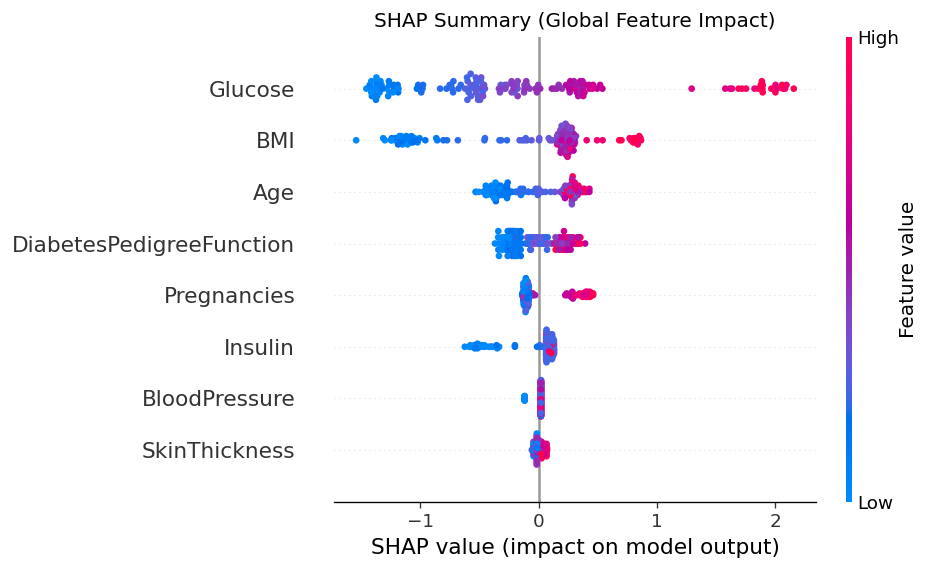

In [22]:
# ============================================
# 19) SHAP EXPLAINABILITY (this is the real portfolio flex)
# We'll explain the tuned XGBoost model.
# ============================================
# Prepare processed matrices for SHAP
imputer = xgb.named_steps["imputer"]
scaler = xgb.named_steps["scaler"]
model = xgb.named_steps["clf"]

X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_train_proc = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train.columns)

X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
X_test_proc = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test.columns)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_proc)

# Global: summary plot
shap.summary_plot(shap_values, X_test_proc, show=False)
plt.title("SHAP Summary (Global Feature Impact)")
plt.show()


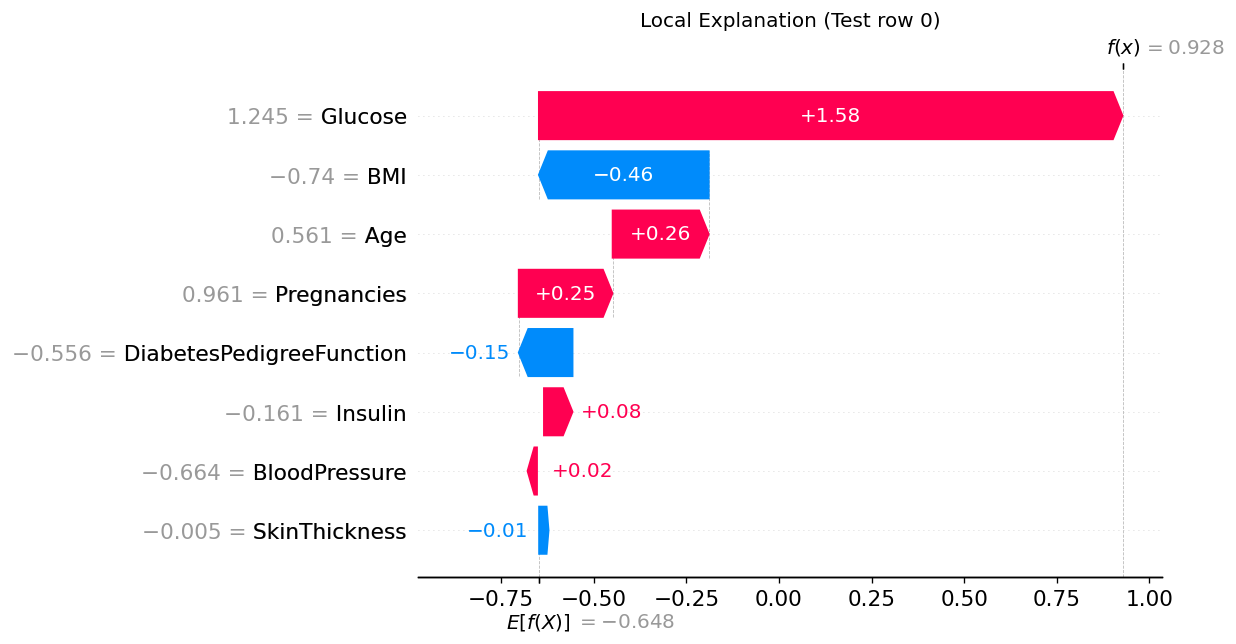

Predicted probability: 0.7166293859481812
True Outcome: 0


In [23]:
# ============================================
# 21) SHAP: Local explanation for one patient (Waterfall)
# ============================================
idx = 0  # change index to explain a different patient
shap_expl = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_proc.iloc[idx].values,
    feature_names=X_test_proc.columns
)

shap.plots.waterfall(shap_expl, show=False)
plt.title(f"Local Explanation (Test row {idx})")
plt.show()

print("Predicted probability:", float(proba_xgb[idx]))
print("True Outcome:", int(y_test.iloc[idx]))


In [24]:
# ============================================
# 22) FINAL: Create a clean results table (portfolio-ready)
# ============================================
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost (tuned)"],
    "ROC-AUC": [
        roc_auc_score(y_test, proba_lr),
        roc_auc_score(y_test, proba_rf),
        roc_auc_score(y_test, proba_xgb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, proba_lr),
        average_precision_score(y_test, proba_rf),
        average_precision_score(y_test, proba_xgb)
    ]
}).sort_values("ROC-AUC", ascending=False)

results


,Model,ROC-AUC,PR-AUC
2,XGBoost (tuned),0.829074,0.702748
1,Random Forest,0.824259,0.708198
0,Logistic Regression,0.811296,0.675828
